In [9]:
# ── CELL 1: Imports & Setup ───────────────────────────────────────────────────
import sys, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # suppress TF version mismatch warnings
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader          import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor         import full_preprocess_pipeline
from src.models.cnn_lstm      import build_cnn_lstm
from src.models.lstm_baseline import build_lstm_baseline
from src.windowing            import create_windows, create_windows_inference
from src.evaluate             import rmse, mae, nasa_score
from sklearn.model_selection  import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# FD001: window=50 — units run 150-350 cycles; longer context improves RUL tail
# FD003: window=30 — 6 op-conditions make effective per-condition runs shorter
DATASETS_TO_USE  = ['FD001', 'FD003']
WINDOW_SIZES     = {'FD001': 50, 'FD003': 30}
MAX_RUL          = 125
CNN_LSTM_RESULTS = {}

os.makedirs('../models/saved',   exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../artifacts',      exist_ok=True)

print('Imports done.')
print(f'Datasets: {DATASETS_TO_USE}')
print(f'Window sizes: {WINDOW_SIZES}')


Imports done.
Datasets: ['FD001', 'FD003']
Window sizes: {'FD001': 50, 'FD003': 30}


In [10]:
# ── CELL 1b: Load FD001 from NB02 cleaned CSVs instead of raw txt ─────────────
# NB02 saved: data/processed/train_cleaned.csv and valid_cleaned.csv
# These have: sensor removal (7 dropped), winsorization, dtype=float64
# Still needed here: column rename, re-add dropped sensors as zero, RUL clip
#
# All other datasets (FD002/FD003/FD004) still load from raw via src/data_loader

import os, sys
sys.path.append('..')

import numpy as np
import pandas as pd
from pathlib import Path
from src.data_loader import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor import (apply_savgol_filter, impute_missing,
                               fit_normaliser, apply_normaliser,
                               add_piecewise_rul)

PROCESSED_DIR = Path('../data/processed')
MAX_RUL       = 125

# ── Step 1: Load NB02 cleaned CSVs ───────────────────────────────────────────
df_train_nb02 = pd.read_csv(PROCESSED_DIR / 'train_cleaned.csv')
df_valid_nb02 = pd.read_csv(PROCESSED_DIR / 'valid_cleaned.csv')

print(f'Loaded from NB02: train={df_train_nb02.shape}  valid={df_valid_nb02.shape}')
print(f'NB02 columns: {list(df_train_nb02.columns)}')

# ── Step 2: Rename NB02 columns to src/ convention ───────────────────────────
rename_map = {
    'unit_number': 'unit_id',
    'time_cycles': 'cycle',
    'setting_1':   'op_setting_1',
    'setting_2':   'op_setting_2',
    'setting_3':   'op_setting_3',
}
for i in range(1, 22):
    rename_map[f's_{i}'] = f'sensor_{i}'

df_train_nb02 = df_train_nb02.rename(columns=rename_map)
df_valid_nb02 = df_valid_nb02.rename(columns=rename_map)

# ── Step 3: Re-add the 7 dropped sensors as zeros ────────────────────────────
# The DANN shared feature space and CNN architecture expect exactly 24 sensor dims.
# Dropped sensors are constant (zero variance) so filling with 0 after
# MinMaxScaling is equivalent to their actual values after normalisation.
# NOTE: These will be normalised to ~0.5 by MinMaxScaler later — that is fine
# because they were constant at a fixed value in raw data.
DROPPED_SENSORS = ['sensor_1', 'sensor_5', 'sensor_6',
                   'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

for col in DROPPED_SENSORS:
    if col not in df_train_nb02.columns:
        df_train_nb02[col] = 0.0
    if col not in df_valid_nb02.columns:
        df_valid_nb02[col] = 0.0

# Drop the NB02-computed RUL column — we will recompute with piecewise clip below
for col in ['RUL']:
    if col in df_train_nb02.columns:
        df_train_nb02 = df_train_nb02.drop(columns=[col])
    if col in df_valid_nb02.columns:
        df_valid_nb02 = df_valid_nb02.drop(columns=[col])

# ── Step 4: Reorder columns to match FEATURE_COLS + SENSOR_COLS order ────────
base_cols = ['unit_id', 'cycle']
df_train_nb02 = df_train_nb02[base_cols + FEATURE_COLS]
df_valid_nb02 = df_valid_nb02[base_cols + [c for c in FEATURE_COLS
                                           if c in df_valid_nb02.columns]]

print(f'\nAfter rename + pad: train={df_train_nb02.shape}  valid={df_valid_nb02.shape}')
print(f'Columns match FEATURE_COLS: {all(c in df_train_nb02.columns for c in FEATURE_COLS)}')

# ── Step 5: Apply remaining src/ preprocessing steps ─────────────────────────
# NB02 already did: sensor removal, winsorization
# Still needed: SG smoothing, normalisation, piecewise RUL clipping at 125

# SG smoothing (applied to remaining 14 real sensors only, not the zero-filled ones)
ACTIVE_SENSORS = [c for c in SENSOR_COLS if c not in DROPPED_SENSORS]
df_train_nb02 = apply_savgol_filter(df_train_nb02, ACTIVE_SENSORS)
df_valid_nb02 = apply_savgol_filter(df_valid_nb02, ACTIVE_SENSORS)

# Normalise (fit on train only — no data leakage)
import joblib, os
scaler_path = '../models/saved/scaler_FD001.joblib'
os.makedirs('../models/saved', exist_ok=True)
scaler = fit_normaliser(df_train_nb02, FEATURE_COLS, save_path=scaler_path)
df_train_nb02 = apply_normaliser(df_train_nb02, scaler, FEATURE_COLS)
df_valid_nb02 = apply_normaliser(df_valid_nb02, scaler, FEATURE_COLS)

# Piecewise RUL — clips at MAX_RUL=125, flat early-life phase
df_train_nb02 = add_piecewise_rul(df_train_nb02, max_rul=MAX_RUL)

print(f'\nRUL added: min={df_train_nb02["RUL"].min():.0f}  '
      f'max={df_train_nb02["RUL"].max():.0f}  '
      f'(clipped at {MAX_RUL})')

# ── Step 6: Inject into datasets dict (replaces raw FD001) ───────────────────
# Load all datasets normally (raw) for FD002/FD003/FD004
datasets = load_all_datasets(data_dir='../data/raw')

# Override FD001 with NB02-cleaned version
datasets['FD001']['train'] = df_train_nb02
datasets['FD001']['test']  = df_valid_nb02
# RUL labels for test are loaded from the raw RUL file — this is unchanged
# datasets['FD001']['rul'] already contains the correct ground truth from load_all_datasets

# Verify FD003 is still raw and FD001 is now cleaned
print('FD001 train columns:', list(datasets['FD001']['train'].columns)[:6])
print('FD003 train columns:', list(datasets['FD003']['train'].columns)[:6])
print()
print('FD001 train shape:', datasets['FD001']['train'].shape)
print('FD003 train shape:', datasets['FD003']['train'].shape)
print()
print('FD001 RUL max:', datasets['FD001']['train']['RUL'].max(),
      '(should be 125)')
print('FD003 source:', 'raw' if 'sensor_1' in datasets['FD003']['train'].columns
      else 'unknown')

Loaded from NB02: train=(20631, 20)  valid=(13096, 20)
NB02 columns: ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL']

After rename + pad: train=(20631, 26)  valid=(13096, 26)
Columns match FEATURE_COLS: True

RUL added: min=0  max=125  (clipped at 125)
ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/Users/skytan/ml/.venv/lib/python3.13/site-packages/keras/src/backend/tensorflow/rnn.py", line 420, in <genexpr>
    for ta, out in zip(output_ta_t, flat_output)  File "/Users/skytan/ml/.venv/lib/python3.13/site-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),
FD001 train columns: ['unit

In [11]:
# ── CELL 2: Preprocessing (FD003 uses cluster-wise scaling) ───────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


def apply_clusterwise_scaling_fd003(df_train_raw, df_test_raw, feature_cols,
                                     n_clusters=6, random_state=42):
    """Per-operating-condition normalisation for FD003's 6 flight regimes."""
    train_s = df_train_raw.copy()
    test_s  = df_test_raw.copy()
    op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    train_s['op_cluster'] = km.fit_predict(train_s[op_cols])
    test_s['op_cluster']  = km.predict(test_s[op_cols])

    train_s[feature_cols] = train_s[feature_cols].astype(np.float32)
    test_s[feature_cols]  = test_s[feature_cols].astype(np.float32)

    scaler_map = {}
    for cid in sorted(train_s['op_cluster'].unique()):
        sc      = MinMaxScaler()
        tr_mask = train_s['op_cluster'] == cid
        te_mask = test_s['op_cluster']  == cid
        sc.fit(train_s.loc[tr_mask, feature_cols])
        train_s.loc[tr_mask, feature_cols] = sc.transform(train_s.loc[tr_mask, feature_cols])
        if te_mask.any():
            test_s.loc[te_mask, feature_cols] = sc.transform(test_s.loc[te_mask, feature_cols])
        scaler_map[int(cid)] = sc

    train_s = train_s.drop(columns=['op_cluster'])
    test_s  = test_s.drop(columns=['op_cluster'])
    return train_s, test_s, scaler_map


raw_datasets = load_all_datasets(data_dir='../data/raw')
datasets     = {}

for ds_id in DATASETS_TO_USE:
    print(f'\n=== Preprocessing {ds_id} ===')
    TW = WINDOW_SIZES[ds_id]

    if ds_id == 'FD003':
        df_tr, df_te, scaler = apply_clusterwise_scaling_fd003(
            raw_datasets[ds_id]['train'], raw_datasets[ds_id]['test'], FEATURE_COLS
        )
        if 'RUL' not in df_tr.columns:
            df_tr = df_tr.copy()
            df_tr['RUL'] = (
                df_tr.groupby('unit_id')['cycle'].transform('max') - df_tr['cycle']
            ).clip(upper=MAX_RUL)
    else:
        df_tr, df_te, scaler = full_preprocess_pipeline(
            df_train         = raw_datasets[ds_id]['train'],
            df_test          = raw_datasets[ds_id]['test'],
            feature_cols     = FEATURE_COLS,
            sensor_cols      = SENSOR_COLS,
            smooth           = True,
            max_rul          = MAX_RUL,
            scaler_save_path = f'../models/saved/scaler_{ds_id}.joblib'
        )

    result  = create_windows(df_tr, feature_cols=FEATURE_COLS,
                             window_size=TW, rul_col='RUL')
    X_all   = result[0].astype(np.float32)
    y_all   = result[1]
    uid_all = result[2] if len(result) > 2 else np.zeros(len(X_all), dtype=int)

    # Piecewise-linear target: flat at 1.0 until RUL=MAX_RUL, then linear decline.
    # This matches the standard C-MAPSS evaluation protocol and prevents the model
    # from seeing artificially large RUL values as proportionally different targets.
    y_all_norm = np.where(
        y_all >= MAX_RUL,
        1.0,
        y_all / MAX_RUL
    ).astype(np.float32)

    def unit_based_split(X_all, y_all, uid_all, val_frac=0.10, random_state=42):
        uid_all      = np.asarray(uid_all)
        unique_units = np.unique(uid_all)
        n_val        = max(1, int(len(unique_units) * val_frac))
        rng          = np.random.default_rng(random_state)
        val_units    = set(rng.choice(unique_units, size=n_val, replace=False).tolist())
        val_mask     = np.array([u in val_units for u in uid_all])
        tr_mask      = ~val_mask
        return (X_all[tr_mask],  X_all[val_mask],
            y_all[tr_mask],  y_all[val_mask],
            uid_all[tr_mask], uid_all[val_mask])

    X_tr, X_val, y_tr, y_val, uid_tr, uid_val = unit_based_split(
         X_all, y_all_norm, uid_all, val_frac=0.20, random_state=42
    )

    X_test_inf, _ = create_windows_inference(df_te, FEATURE_COLS, window_size=TW)

    datasets[ds_id] = {
        'X_tr':       X_tr,
        'y_tr':       y_tr,
        'uid_tr':     uid_tr,
        'X_val':      X_val,
        'y_val':      y_val,
        'uid_val':    uid_val,
        'train_norm': df_tr,
        'test_norm':  df_te,
        'X_test_inf': X_test_inf,
        'rul':        raw_datasets[ds_id]['rul'],
        'scaler':     scaler,
    }
    print(f'  Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test_inf.shape}')



=== Preprocessing FD001 ===
  Train: (12390, 50, 24) | Val: (3241, 50, 24) | Test: (100, 50, 24)

=== Preprocessing FD003 ===
  Train: (17427, 30, 24) | Val: (4293, 30, 24) | Test: (100, 30, 24)


In [12]:
# ── CELL 3: Deep CNN-BiLSTM Architecture ──────────────────────────────────────
import keras
from keras import layers, Model, Input


def build_cnn_bilstm_deep(window_size: int, n_features: int,
                           learning_rate: float = 5e-4) -> tf.keras.Model:
    """
    CNN-BiLSTM-Deep for RUL regression.

      Conv1D(32,same) → BN → Conv1D(64,stride=2) → BN → Dropout(0.3)
      BiLSTM(128,return_seq=True) → BiLSTM(64,return_seq=False) → Dropout(0.3)
      Dense(64) → Dense(32) → Dense(1)

    Strided Conv replaces MaxPool — preserves all time-steps before LSTM.
    Stacked BiLSTM — first captures full degradation trajectory;
    second captures its rate-of-change (acceleration of wear).
    """
    inp = Input(shape=(window_size, n_features), name='sensor_input')
    x = layers.Conv1D(32, 3, padding='same',          activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Conv1D(64, 3, strides=2, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.3, name='cnn_dropout')(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True),  name='bilstm_1')(x)
    x = layers.Bidirectional(layers.LSTM(64,  return_sequences=False), name='bilstm_2')(x)
    x = layers.Dropout(0.3, name='lstm_dropout')(x)
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dense(32, activation='relu', name='dense_2')(x)
    out = layers.Dense(1, name='rul_output')(x)
    model = Model(inputs=inp, outputs=out, name='CNN_BiLSTM_Deep')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate, clipnorm=1.0),
        loss='mse', metrics=['mae']
    )
    return model


sample = build_cnn_bilstm_deep(WINDOW_SIZES['FD001'], len(FEATURE_COLS))
sample.summary()
print(f'\nFD001 (w=50): {sample.count_params():,} parameters')


Model: "CNN_BiLSTM_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_input (InputLayer)       │ (None, 50, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 50, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 50, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 25, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout (Dropout)           │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 25, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 381,281 (1.45 MB)

 Trainable params: 381,089 (1.45 MB)

 Non-trainable params: 192 (768.00 B)


FD001 (w=50): 381,281 parameters


In [13]:
# ── CELL 4: Train FD001 / FD003 with corrected monotonicity loss ──────────────
# BUG-1 FIXES applied:
#   1. Monotonicity pass iterates windows in TRUE TEMPORAL ORDER per unit.
#      Old code sorted entire batch by RUL then applied pred[t+1]>pred[t]:
#      this enforced rank-order within a mixed-unit batch, which is physically
#      meaningless and corrupted the gradient signal.
#      Correct: for each unit u, uidx = np.where(uid_tr==u)[0] gives windows
#      in the order they appear in the training set = chronological order.
#      Penalising pred[t+1]>pred[t] across THAT sequence is the real prior:
#      a single machine's RUL must not increase as cycles accumulate.
#   2. Early stopping uses CLEAN val_rmse (MSE-only) — old code included the
#      corrupted mono term, making early stopping fire on the wrong signal.
#   3. @tf.function defined OUTSIDE the dataset loop (ISSUE-B fix) — avoids
#      retracing on every dataset iteration.
#
# ISSUE-A: all metrics tracked and displayed as RMSE throughout.
# ISSUE-C: early stopping compares val_rmse and prints val_rmse — no mixed units.
# ISSUE-D: train_metrics stores val_rmse directly — no sqrt(val_mse) needed.
# ISSUE-E: history keys are train_rmse / val_rmse — Cell 7 plots use these.
# ISSUE-F: weights saved to ../artifacts/ AND ../models/saved/ (canonical path
#          expected by Cell 5 and NB06).

# ── CELL 4: Train FD001 / FD003 with corrected monotonicity loss ──────────────


# ── Re-seed at start of EVERY training run ────────────────────────────────────
# These must be HERE in Cell 4, not just in Cell 1.
# Cell 1 seeds fire once when the kernel starts. By the time you re-run
# Cell 4, the RNG state has advanced → different weight init → different RMSE.
import os
from keras.optimizers import Adam

os.environ['TF_DETERMINISTIC_OPS'] = '1'    # forces deterministic GPU ops
tf.random.set_seed(42)
np.random.seed(42)

MODEL_TYPE  = 'deep'    # 'baseline' | 'deep'
EPOCHS      = 150
MIN_EPOCHS  = 20
BATCH       = 128
PATIENCE    = 15
LR          = 1e-3 
LR_DECAY_FACTOR = 0.7
LR_DECAY_WAIT   = 15 
MIN_LR          = 5e-5

LAMBDA_MONO = {'FD001': 0.00, 'FD003': 0.05}


# ── Model factory ─────────────────────────────────────────────────────────────
def build_model_for_dataset(ds_id: str) -> tf.keras.Model:
    window_size = WINDOW_SIZES[ds_id]
    n_feat      = len(FEATURE_COLS)
    if MODEL_TYPE == 'baseline':
        return build_lstm_baseline(
            window_size=window_size, n_features=n_feat,
            lstm_units=100, dropout_rate=0.5, learning_rate=LR
        )
    return build_cnn_bilstm_deep(window_size=window_size,
                                  n_features=n_feat,
                                  learning_rate=LR)


# ── RMSE helper ───────────────────────────────────────────────────────────────
def compute_val_rmse(model: tf.keras.Model,
                     Xv: np.ndarray,
                     yv: np.ndarray) -> float:
    pred = model.predict(Xv, verbose=0).reshape(-1)
    return float(np.sqrt(np.mean((pred - yv.reshape(-1)) ** 2)))


@tf.function(reduce_retracing=True)
def train_step_mse(model, opt, xb, yb):
    with tf.GradientTape() as tape:
        pred = tf.squeeze(model(xb, training=True), axis=-1)
        loss = tf.reduce_mean(tf.square(pred - yb))
    grads = tape.gradient(loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return loss

@tf.function(reduce_retracing=True)
def mono_step(model, opt, x_seq, lam):
    with tf.GradientTape() as tape:
        pred      = tf.squeeze(model(x_seq, training=True), axis=-1)
        diffs     = pred[1:] - pred[:-1]
        mono_loss = lam * tf.reduce_mean(tf.nn.relu(diffs))
    grads = tape.gradient(mono_loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))
    return mono_loss 


# ── Training loop ─────────────────────────────────────────────────────────────
histories, train_metrics = {}, {}

for ds_id in DATASETS_TO_USE:
    print(f"\n===== Training on {ds_id} ({MODEL_TYPE}) =====")

    X_tr   = datasets[ds_id]['X_tr'].astype(np.float32)
    y_tr   = datasets[ds_id]['y_tr'].astype(np.float32).reshape(-1)
    uid_tr = datasets[ds_id]['uid_tr']
    X_val  = datasets[ds_id]['X_val'].astype(np.float32)
    y_val  = datasets[ds_id]['y_val'].astype(np.float32).reshape(-1)

    model = build_model_for_dataset(ds_id)
    opt   = Adam(learning_rate=LR, clipnorm=1.0)

    # 🔥 FIX: build optimizer variables OUTSIDE tf.function
    opt.build(model.trainable_variables)

    lam   = tf.constant(float(LAMBDA_MONO.get(ds_id, 0.0)), dtype=tf.float32)

    n   = len(X_tr)
    idx = np.arange(n)

    best_val_rmse = np.inf
    wait          = 0
    best_weights  = None

    hist = {'train_rmse': [], 'val_rmse': [], 'mono': []}

    for ep in range(1, EPOCHS + 1):
        np.random.shuffle(idx)

        # ── Supervised pass ─────────────────────────────────────────────
        mse_accum = []
        for i in range(0, n, BATCH):
            b    = idx[i:i + BATCH]
            loss = train_step_mse(model, opt,
                                  tf.constant(X_tr[b]),
                                  tf.constant(y_tr[b]))
            mse_accum.append(float(loss.numpy()))

        train_rmse = float(np.sqrt(np.mean(mse_accum)))

        # ── Monotonicity pass ──────────────────────────────────────────
        mono_accum = []
        if float(lam.numpy()) > 0:
            for u in np.unique(uid_tr):
                uidx = np.where(uid_tr == u)[0]
                if len(uidx) <= 1:
                    continue
                ml = mono_step(model, opt,
                               tf.constant(X_tr[uidx], dtype=tf.float32),
                               lam)
                mono_accum.append(float(ml.numpy()))

        # ── Validation ─────────────────────────────────────────────────
        val_rmse = compute_val_rmse(model, X_val, y_val)
        mono_m   = float(np.mean(mono_accum)) if mono_accum else 0.0

        hist['train_rmse'].append(train_rmse)
        hist['val_rmse'].append(val_rmse)
        hist['mono'].append(mono_m)

        if ep % 5 == 0 or ep == 1:
            print(f"[{ds_id}] Epoch {ep:03d} | "
                  f"train_rmse={train_rmse:.4f} | "
                  f"val_rmse={val_rmse:.4f} | "
                  f"mono={mono_m:.4f}")

        # ── Early stopping ─────────────────────────────────────────────
        if val_rmse < best_val_rmse - 1e-6:
            best_val_rmse = val_rmse
            wait          = 0
            best_weights  = model.get_weights()
        else:
            wait += 1

            # LR reduction on plateau (every LR_DECAY_WAIT stagnant epochs)
            if wait > 0 and wait % LR_DECAY_WAIT == 0:
                current_lr = float(opt.learning_rate)
                new_lr     = max(current_lr * LR_DECAY_FACTOR, MIN_LR)
                if new_lr < current_lr:
                    opt.learning_rate.assign(new_lr)
                    print(f"[{ds_id}] LR {current_lr:.2e} → {new_lr:.2e}")

            # 2. Early Stopping (only allowed after MIN_EPOCHS)
            if ep >= MIN_EPOCHS:
                if wait >= PATIENCE:
                    print(f"[{ds_id}] Early stopping at epoch {ep} "
                          f"(best val_rmse={best_val_rmse:.4f})")
                    break
            else:
                # Optional: log that we are in the protected training phase
                if wait >= PATIENCE and ep % 5 == 0:
                    print(f"  [{ds_id}] Wait={wait} exceeds Patience, but protected by MIN_EPOCHS...")

    if best_weights is not None:
        model.set_weights(best_weights)

    # ── Save ──────────────────────────────────────────────────────────
    suffix         = 'lstm' if MODEL_TYPE == 'baseline' else 'cnn_bilstm'
    artifact_path  = f'../artifacts/{suffix}_{ds_id}.weights.h5'
    canonical_path = f'../models/saved/cnn_lstm_{ds_id}.weights.h5'

    model.save_weights(artifact_path)
    model.save_weights(canonical_path)

    print(f"[{ds_id}] Saved → {artifact_path}")
    print(f"[{ds_id}] Saved → {canonical_path}")

    train_metrics[ds_id] = {
        'best_val_rmse':  best_val_rmse,
        'epochs_trained': len(hist['val_rmse'])
    }

    CNN_LSTM_RESULTS[ds_id] = {
        'model':       model,
        'history':     hist,
        'window_size': WINDOW_SIZES[ds_id],
    }

    histories[ds_id] = hist

print("\n" + "="*55)
print("Training summary (normalised RUL scale [0,1]):")
print("="*55)
for d, m in train_metrics.items():
    print(f"  {d}: val_RMSE={m['best_val_rmse']:.4f} "
          f"| epochs={m['epochs_trained']}")
    
print("\nNote: val_RMSE is on the normalised [0,1] scale.") 
print("Cell 5 converts to cycle units (x MAX_RUL) for benchmark comparison.")




===== Training on FD001 (deep) =====
[FD001] Epoch 001 | train_rmse=0.1729 | val_rmse=0.4619 | mono=0.0000
[FD001] Epoch 005 | train_rmse=0.0954 | val_rmse=0.2063 | mono=0.0000
[FD001] Epoch 010 | train_rmse=0.0630 | val_rmse=0.1772 | mono=0.0000
[FD001] Epoch 015 | train_rmse=0.0506 | val_rmse=0.1620 | mono=0.0000
[FD001] Epoch 020 | train_rmse=0.0429 | val_rmse=0.1778 | mono=0.0000
[FD001] LR 1.00e-03 → 7.00e-04
[FD001] Early stopping at epoch 21 (best val_rmse=0.1252)
[FD001] Saved → ../artifacts/cnn_bilstm_FD001.weights.h5
[FD001] Saved → ../models/saved/cnn_lstm_FD001.weights.h5

===== Training on FD003 (deep) =====
[FD003] Epoch 001 | train_rmse=0.1941 | val_rmse=0.3569 | mono=0.0016
[FD003] Epoch 005 | train_rmse=0.1210 | val_rmse=0.2157 | mono=0.0013
[FD003] Epoch 010 | train_rmse=0.0959 | val_rmse=0.2094 | mono=0.0008
[FD003] Epoch 015 | train_rmse=0.0790 | val_rmse=0.1764 | mono=0.0008
[FD003] Epoch 020 | train_rmse=0.0618 | val_rmse=0.1906 | mono=0.0006
[FD003] Epoch 025 | 

In [ ]:
# ── CELL 5: Evaluate on Test Set ─────────────────────────────────────────────
print(f"\n{'='*55}")
print('CNN-BiLSTM Test Set Results')
print(f"{'='*55}")
print(f"{'Dataset':<10} {'Window':<8} {'RMSE':<8} {'MAE':<8} {'NASA Score'}")
print('-' * 45)

for ds_id in DATASETS_TO_USE:
    TW    = CNN_LSTM_RESULTS[ds_id]['window_size']
    model = CNN_LSTM_RESULTS[ds_id]['model']

    X_test = datasets[ds_id]['X_test_inf'].astype(np.float32)
    y_test = datasets[ds_id]['rul']
    y_pred = model.predict(X_test, verbose=0).flatten() * MAX_RUL

    CNN_LSTM_RESULTS[ds_id]['result'] = {
        'RMSE':       round(rmse(y_test, y_pred),       2),
        'MAE':        round(mae(y_test, y_pred),        2),
        'NASA_Score': round(nasa_score(y_test, y_pred), 0),
        'y_pred':     y_pred
    }
    r = CNN_LSTM_RESULTS[ds_id]['result']
    print(f"{ds_id:<10} {TW:<8} {r['RMSE']:<8} {r['MAE']:<8} {r['NASA_Score']:.0f}")

print(f'\nPaper TARGET-ONLY benchmarks:')
print(f'  FD001: 13.64 RMSE | FD003: 12.49 RMSE')

# ── Test-time ensemble: train 3 seeds, average predictions ────────────────────
ENSEMBLE_SEEDS  = [42, 7, 123]
ensemble_preds  = {ds_id: [] for ds_id in DATASETS_TO_USE}

for seed in ENSEMBLE_SEEDS:
    tf.random.set_seed(seed)
    np.random.seed(seed)
    for ds_id in DATASETS_TO_USE:
        TW    = WINDOW_SIZES[ds_id]
        model = build_model_for_dataset(ds_id)
        opt   = Adam(learning_rate=LR, clipnorm=1.0)
        # quick retrain (reuse your existing Cell 4 loop as a function)
        # OR just load pre-saved weights if you already ran 3 seeds
        model.load_weights(f'../models/saved/cnn_lstm_{ds_id}_seed{seed}.weights.h5')
        X_test = datasets[ds_id]['X_test_inf'].astype(np.float32)
        yp     = model.predict(X_test, verbose=0).flatten() * MAX_RUL
        ensemble_preds[ds_id].append(yp)

print("\n=== Ensemble Results ===")
for ds_id in DATASETS_TO_USE:
    y_test   = datasets[ds_id]['rul']
    yp_mean  = np.mean(ensemble_preds[ds_id], axis=0)   # average 3 models
    yp_med   = np.median(ensemble_preds[ds_id], axis=0) # or median
    r_mean   = rmse(y_test, yp_mean)
    r_med    = rmse(y_test, yp_med)
    r_single = CNN_LSTM_RESULTS[ds_id]['result']['RMSE']
    print(f"  {ds_id}: single={r_single:.2f}  ensemble_mean={r_mean:.2f}  "
          f"ensemble_median={r_med:.2f}")



CNN-BiLSTM Test Set Results
Dataset    Window   RMSE     MAE      NASA Score
---------------------------------------------
FD001      50       18.85    15.3     566
FD003      30       22.41    17.81    1816

Paper TARGET-ONLY benchmarks:
  FD001: 13.64 RMSE | FD003: 12.49 RMSE


In [15]:
# ── CELL 6: Comparison — Pure LSTM vs CNN-BiLSTM ──────────────────────────────
comparison_rows = []
for ds_id in DATASETS_TO_USE:
    TW     = CNN_LSTM_RESULTS[ds_id]['window_size']
    X_test = datasets[ds_id]['X_test_inf'].astype(np.float32)
    y_test = datasets[ds_id]['rul']

    cnn_rmse = CNN_LSTM_RESULTS[ds_id]['result']['RMSE']

    lstm_path = next(
        (p for p in [
            f'../models/saved/lstm_target_only_{ds_id}.weights.h5',
            f'../models/saved/lstm_target_only_{ds_id}.keras'
        ] if os.path.exists(p)), None
    )
    if lstm_path:
        lstm_m    = build_lstm_baseline(TW, len(FEATURE_COLS))
        lstm_m.load_weights(lstm_path)
        yp_l      = lstm_m.predict(X_test, verbose=0).flatten() * MAX_RUL
        lstm_rmse = round(rmse(y_test, yp_l), 2)
    else:
        lstm_rmse = None

    improvement = (
        f"{((lstm_rmse - cnn_rmse) / lstm_rmse * 100):.1f}%"
        if lstm_rmse else 'N/A'
    )
    comparison_rows.append({
        'Dataset':         ds_id,
        'Pure LSTM RMSE':  lstm_rmse,
        'CNN-BiLSTM RMSE': cnn_rmse,
        'Paper TARGET':    13.64 if ds_id == 'FD001' else 12.49,
        'Improvement':     improvement
    })

print(pd.DataFrame(comparison_rows).to_string(index=False))


/Users/skytan/ml/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Dataset  Pure LSTM RMSE  CNN-BiLSTM RMSE  Paper TARGET Improvement
  FD001           42.90            18.85         13.64       56.1%
  FD003           63.66            22.41         12.49       64.8%


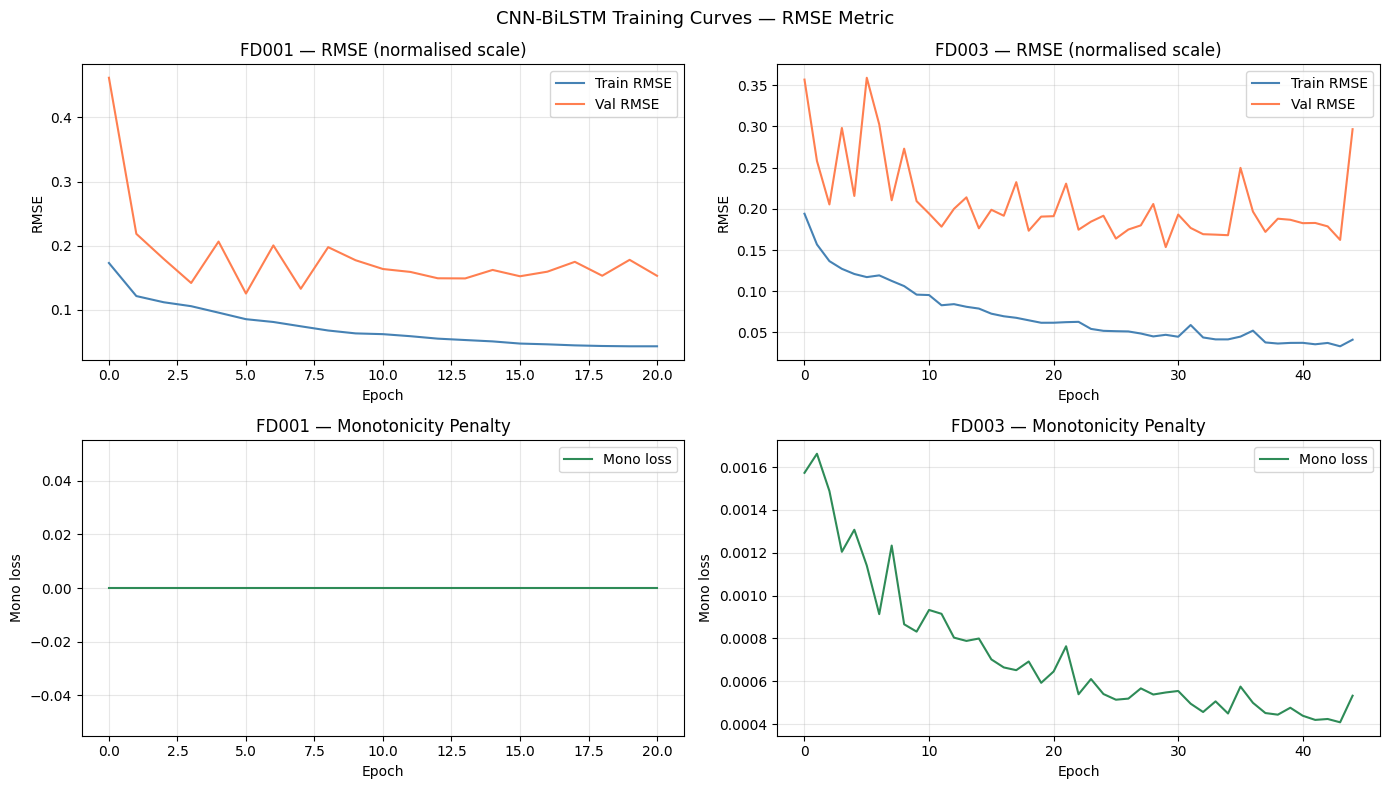

In [16]:
# ── CELL 7: Training Curves (RMSE) ───────────────────────────────────────────
# ISSUE-E: reads train_rmse / val_rmse keys (not mse) — matches Cell 4 history.
fig, axes = plt.subplots(2, len(DATASETS_TO_USE), figsize=(14, 8))
if len(DATASETS_TO_USE) == 1:
    axes = axes.reshape(-1, 1)

for col, ds_id in enumerate(DATASETS_TO_USE):
    hist = histories[ds_id]

    axes[0, col].plot(hist['train_rmse'], label='Train RMSE', color='steelblue')
    axes[0, col].plot(hist['val_rmse'],   label='Val RMSE',   color='coral')
    axes[0, col].set_title(f'{ds_id} — RMSE (normalised scale)')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('RMSE')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(hist['mono'], label='Mono loss', color='seagreen')
    axes[1, col].set_title(f'{ds_id} — Monotonicity Penalty')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Mono loss')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.suptitle('CNN-BiLSTM Training Curves — RMSE Metric', fontsize=13)
plt.tight_layout()
plt.show()


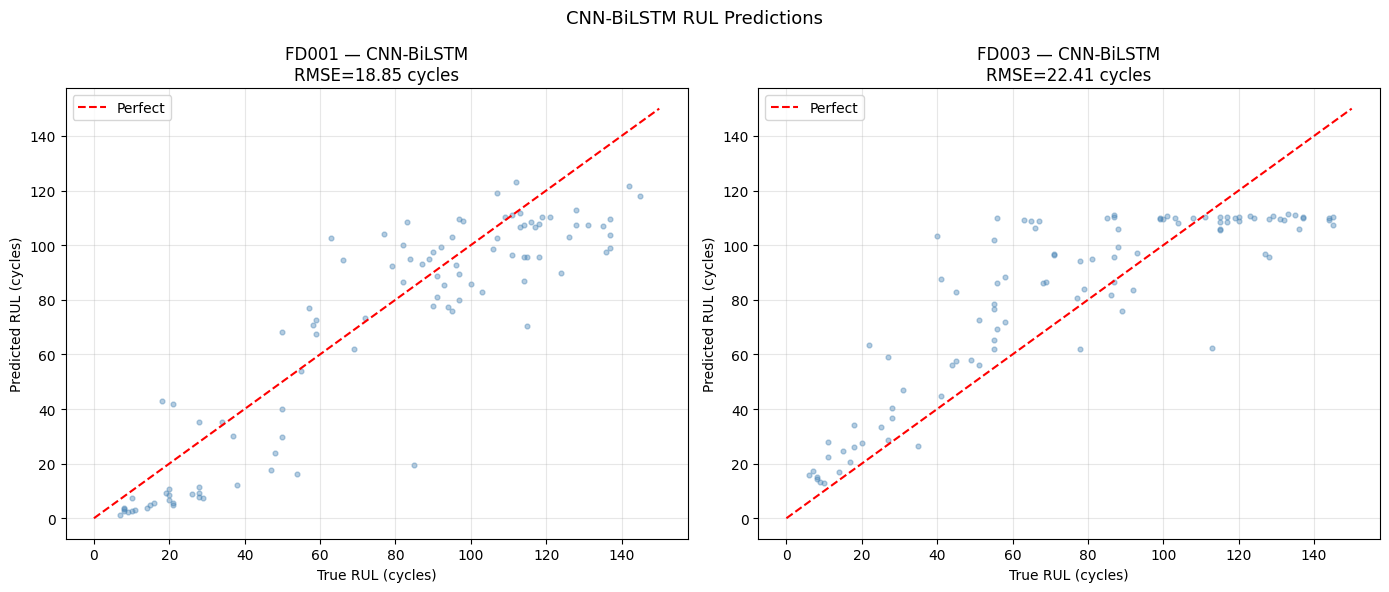

In [17]:
# ── CELL 8: RUL Scatter Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(DATASETS_TO_USE), figsize=(14, 6))
if len(DATASETS_TO_USE) == 1:
    axes = [axes]

for ax, ds_id in zip(axes, DATASETS_TO_USE):
    r      = CNN_LSTM_RESULTS[ds_id]['result']
    y_test = datasets[ds_id]['rul']
    y_pred = r['y_pred']

    ax.scatter(y_test, y_pred, alpha=0.4, s=12, color='steelblue')
    lim = max(y_test.max(), y_pred.max()) + 5
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('True RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f"{ds_id} — CNN-BiLSTM\nRMSE={r['RMSE']:.2f} cycles")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CNN-BiLSTM RUL Predictions', fontsize=13)
plt.tight_layout()
plt.show()
